# Week 7: Tidy Data / Relational Data - Class Exercises

We first load the packages necessary for this exercise.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from itables import show

---
## 1. International Visitor Arrivals in Singapore

In this question, we revisit the tourist data we came across previously.\
The file `tourist.csv` (available from `Canvas > Files > data`) contains monthly international visitor arrivals by length of stay from July to December in 2023, 
retrieved from the Singapore Department of Statistics. \
Let’s start by reading in the data as `df`.

In [2]:
# data for q1
df = pd.read_csv('../data/tourist.csv')
print(df)

       Data Series  2023 Dec  2023 Nov  2023 Oct  2023 Sep  2023 Aug  2023 Jul
0      Under 1 Day    259568    240351    236035    227788    248805    269994
1            1 Day    189997    181139    175731    166190    190444    202319
2           2 Days    162209    177977    181721    167772    197076    205910
3           3 Days    168788    168898    189215    172901    210238    216598
4           4 Days    117981    105229    126509    114319    162079    160111
5           5 Days     64785     56366     69110     62421     98284     98065
6           6 Days     38500     31919     37922     37647     52957     58609
7           7 Days     25082     21058     24014     25955     32983     37887
8        8-10 Days     31446     26251     29618     29818     39565     43611
9       11-14 Days     19370     15348     16519     16837     24048     25987
10  15 Days & Over     36116     32110     33901     34642     51712     47266
11      15-29 Days     25795     22262     23288    

(A) Tidy the data and store the result in a data frame named `q1a`. Specifically:
- Remove the rows for the arrival category "15 Days & Over".
- Reshape the data into a tidy format.
- From the `month` column, extract numeric `year` and numeric `month`.
- Keep only these columns: `year`, `month`, `Data Series`, and `arrivals`. 

The first two rows of resulting data frame should look like:

|   |year  | month | Data Series | arrivals |
|---|------|-------|-------------|----------|
| 0 | 2023 | 12    | Under 1 Day | 259568   |
| 1 | 2023 | 12    | 1 Day       | 189997   |

In [3]:
# Type your code here:
# 1. Remove rows for the arrival category "15 Days & Over"
df_filtered = df[df['Data Series'] != '15 Days & Over'].copy()

# 2. Reshape the data into a tidy format
q1a = df_filtered.melt(id_vars=['Data Series'], 
                       var_name='month_str', 
                       value_name='arrivals')

# 3. Extract numeric year and numeric month
date_series = pd.to_datetime(q1a['month_str'], format='%Y %b', errors='coerce')
q1a['year'] = date_series.dt.year
q1a['month'] = date_series.dt.month

# 4. Keep only the specified columns
q1a = q1a[['year', 'month', 'Data Series', 'arrivals']]
q1a.head(2)

,year,month,Data Series,arrivals
0,2023,12,Under 1 Day,259568
1,2023,12,1 Day,189997


(B) Calculate the total international arrivals for each month.
- Store the results in a data frame named `q1b`.
- Keep only these columns in `q1b`: `month` and `arrivals`.
- Display all the rows of `q1b`.

In [4]:
# Type your code here:
# 1. Group by month and calculate the sum of arrivals
# 2. Store the result in a new data frame q1b
q1b = q1a.groupby('month')['arrivals'].sum().reset_index()

# 3. Ensure q1b only contains 'month' and 'arrivals'
q1b = q1b[['month', 'arrivals']]

# 4. Display all rows of q1b
with pd.option_context('display.max_rows', None):
    print(q1b)

   month  arrivals
0      7   1366357
1      8   1308191
2      9   1056290
3     10   1120295
4     11   1056646
5     12   1113842


(C) Using `q1b`, calculate the month-on-month rate of change in total tourist arrivals from August to December 2023.
- Store the results in a new data frame named `q1c`, with the percentage change rate saved in a column named `rate`.
- Keep only these columns in `q1c`: `month`, `arrivals` and `rate`.
- Display all the rows of `q1c`.

**Hint**: $\displaystyle \text{rate}_i = \frac{\text{arrival}_i-\text{arrival}_{i-1}}{\text{arrival}_{i-1}} \times 100.$

In [5]:
# Type your code here:
# 1. Start with a copy of q1b
q1c = q1b.copy()

# 2. Calculate the rate of change (%)
q1c['rate'] = q1c['arrivals'].pct_change() * 100

# 3. Filter: Remove rows where 'rate' is NaN (the very first month)
q1c = q1c.dropna(subset=['rate'])

# 4. Select columns and display
q1c = q1c[['month', 'arrivals', 'rate']]

with pd.option_context('display.max_rows', None):
    print(q1c)


   month  arrivals       rate
1      8   1308191  -4.257013
2      9   1056290 -19.255674
3     10   1120295   6.059416
4     11   1056646  -5.681450
5     12   1113842   5.412977


(D) Using `q1c`, re-create, as closely as you can, the bar plot below to visualize month-on-month rate of change in total tourist arrivals from August to December 2023.

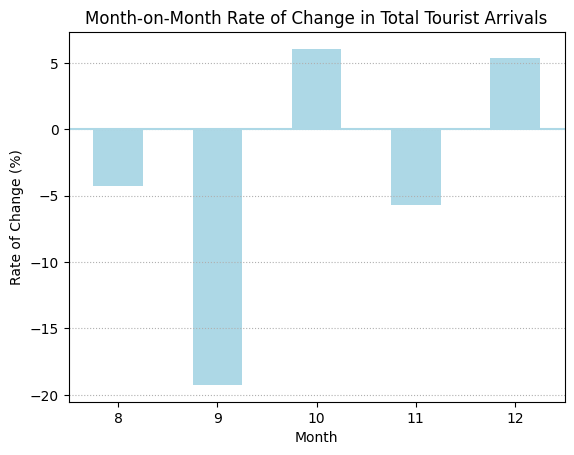

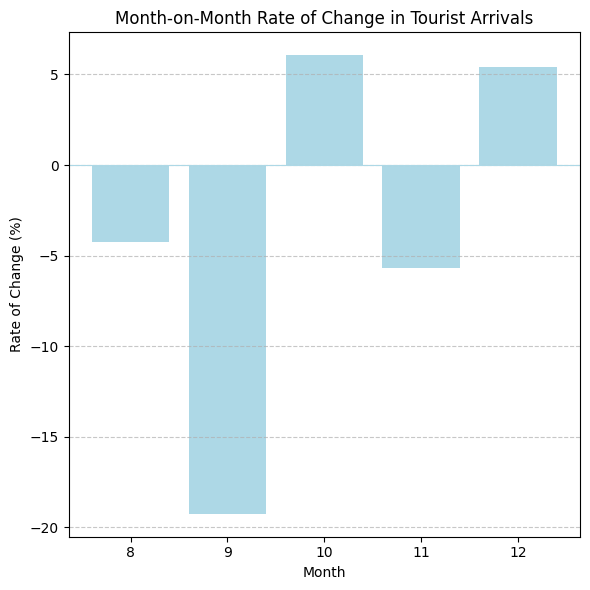

In [6]:
# Type your code here:
plt.figure(figsize=(6, 6))
plt.bar(q1c['month'], q1c['rate'].fillna(0), color='lightblue')
plt.title('Month-on-Month Rate of Change in Tourist Arrivals', fontsize=12)
plt.xlabel('Month', fontsize=10)
plt.ylabel('Rate of Change (%)', fontsize=10)
plt.xticks(q1c['month'])
plt.axhline(0, color='lightblue', linewidth=0.8)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()


---
## 2. Flight Cancellations
In this question, we will use the `flights` and `airports` tables from the `nycflights13` data set.

The files `flights.csv.zip` and `airports.csv` are available in `Canvas > Files > data > nycflights13`.\
Let’s start by reading in the two tables and displaying them.

In [7]:
# data for q2
flights  = pd.read_csv("../data/nycflights13/flights.csv.zip")
airports = pd.read_csv("../data/nycflights13/airports.csv")

show(flights)
show(airports)

Loading ITables v2.7.0 from the internet... (need help?)


Loading ITables v2.7.0 from the internet... (need help?)


(A) Filter the `flights` table to keep only flights operated by United Airlines (UA).
- Define a flight to be cancelled if the departure time is missing.
- For each `origin` and `month`, compute the cancellation rate.
- Store the result in a tidy data frame named `q2a`.

The first two rows of `q2a` should look like this:

|   | origin | month | total | cancelled | rate     |
|---|--------|-------|-------|-----------|----------|
| 0 | EWR    | 1     | 3657  | 21        | 0.574241 |
| 1 | EWR    | 2     | 3433  | 131       | 3.815904 |

In [8]:
# Type your code here:
# 1. Filter for United Airlines (UA)
ua_flights = flights[flights['carrier'] == 'UA'].copy()
# 2. Define cancellation (True if dep_time is NaN)
ua_flights['cancelled_bool'] = ua_flights['dep_time'].isna()
# 3. Compute total, cancelled count, and rate
q2a = ua_flights.groupby(['origin', 'month']).agg(
    total=('cancelled_bool', 'count'),
    cancelled=('cancelled_bool', 'sum')
).reset_index()
# 4. Calculate the rate
q2a['rate'] = q2a['cancelled'] / q2a['total'] * 100
q2a.head(2)

,origin,month,total,cancelled,rate
0,EWR,1,3657,21,0.574241
1,EWR,2,3433,131,3.815904


(B) Join `q2a` with the `airports` table to add the corresponding airport names for each origin airport code.
- Next, pivot the table to wide format so that each airport has its own column listing it's cancellation rates for each month.
- The resulting data frame `q2b` should look like this.

|   | month	| John F Kennedy Intl | La Guardia | Newark Liberty Intl |
|---|-------|---------------------|------------|---------------------|
| 0	| Jan	| 0.263158	          | 1.666667   | 0.574241            |
| 1	| Feb	| 4.651163	          | 5.799649   | 3.815904            |

- Using `q2b`, re-create, as closely as you can, the following time series line plot to visualize the flight cancellation rates across months for each origin airport.

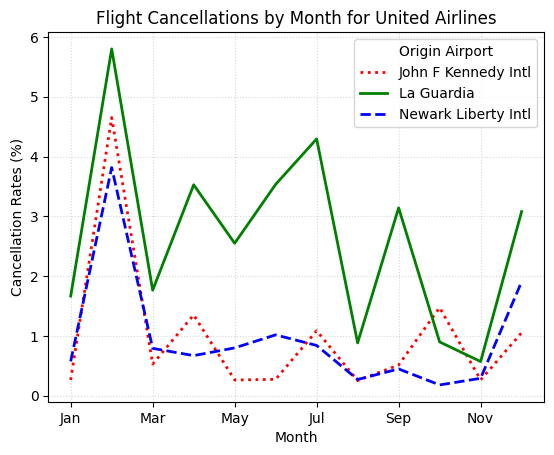

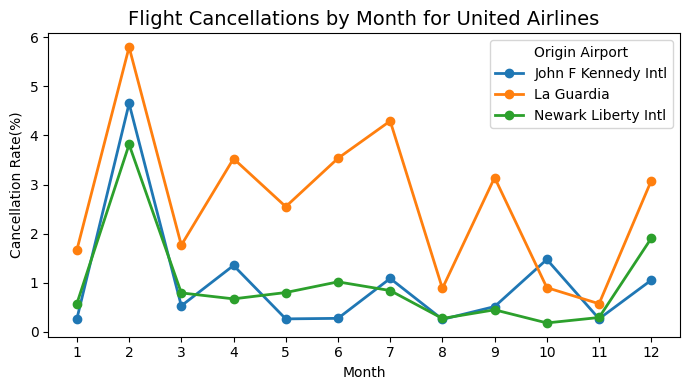

In [ ]:
# Type your code here:
# 1. Join q2a with airports table to get airport names
q2b_joined = q2a.merge(airports[['faa', 'name']], left_on='origin', right_on='faa', how='left')
q2b = q2b_joined.pivot(index='month', columns='name', values='rate')
plt.figure(figsize=(7, 4))
plt.plot(q2b.index, q2b.values, marker='o', linewidth=2)
plt.title('Flight Cancellations by Month for United Airlines', fontsize=14)
plt.xlabel('Month', fontsize=10)
plt.ylabel('Cancellation Rate(%)', fontsize=10)
plt.xticks(range(1, 13))
plt.legend(q2b.columns, title='Origin Airport', loc='best', frameon=True)
plt.tight_layout()
plt.show()
